In [1]:
import pickle
import random

import torch

# Fix the kernel dying?
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

from eval_knn_proto import *

In [2]:
tensor_dict_path = "C:\\Users\\kdmen\\Repos\\pers-gest-cls\\dataset\\segfilt_rts_tensor_dict.pkl"

with open(tensor_dict_path, "rb") as f:
    full_dict = pickle.load(f)
    tensor_dict = full_dict['data']

In [3]:
# NOTE: the index after PID is now gesture CLASS, NOT gesture num!!

# Pick one user, two gestures, check if they're actually different
pid = 'P011'
g1 = tensor_dict[pid][1]['emg']  # (10, 64, 16)
g2 = tensor_dict[pid][2]['emg']

# Are they meaningfully different?
print("G1 mean:", g1.mean().item(), "std:", g1.std().item())
print("G2 mean:", g2.mean().item(), "std:", g2.std().item())
print("G1 vs G2 L1 dist (trial 0):", (g1[0] - g2[0]).abs().mean().item())
print("G1 vs G1 L1 dist (trial 0 vs 1):", (g1[0] - g1[1]).abs().mean().item())

G1 mean: 1.4901161415892261e-09 std: 1.0000488758087158
G2 mean: 3.7252903539730653e-10 std: 1.0000488758087158
G1 vs G2 L1 dist (trial 0): 0.5924422740936279
G1 vs G1 L1 dist (trial 0 vs 1): 0.4628170132637024


In [4]:
import torch
import matplotlib.pyplot as plt
from typing import Optional, Union, Dict

def ensure_channel_first(x: torch.Tensor) -> torch.Tensor:
    """Helper from eval_knn_proto.py to ensure (N, C, T) shape."""
    if x is None or x.dim() != 3:
        return x
    # If the last dimension matches known channel counts, swap it
    if x.shape[-1] in [16, 72]:
        return x.permute(0, 2, 1)
    return x

def plot_pca_variance(
    data: Union[torch.Tensor, Dict], 
    pid: Optional[Union[str, int]] = None,
    imu_data: Optional[torch.Tensor] = None, 
    save_path: str = "pca_variance_analysis.png"
):
    """
    Analyzes PCA variance. 
    Accepts either:
      1. A tensor_dict + pid (automatically extracts and cats all gestures)
      2. Raw EMG and IMU tensors (N, C, T)
    """
    emg_tensor = None
    imu_tensor = imu_data

    # --- Data Extraction Logic ---
    if isinstance(data, dict):
        # If it's the full tensor_dict, we need to pick a participant
        target_pid = pid if pid is not None else list(data.keys())[0]
        user_data = data[target_pid]
        
        emg_list, imu_list = [], []
        # Flatten across all gestures for this user to get a global variance view
        for gid in user_data.keys():
            if 'emg' in user_data[gid]:
                emg_list.append(ensure_channel_first(user_data[gid]['emg']))
            if 'imu' in user_data[gid] and user_data[gid]['imu'] is not None:
                imu_list.append(ensure_channel_first(user_data[gid]['imu']))
        
        emg_tensor = torch.cat(emg_list, dim=0) if emg_list else None
        imu_tensor = torch.cat(imu_list, dim=0) if imu_list else None
        print(f"Aggregated {len(emg_list)} gestures for PID {target_pid}")
    else:
        emg_tensor = ensure_channel_first(data)
        imu_tensor = ensure_channel_first(imu_data)

    # --- PCA Calculation Logic ---
    def get_cum_variance(x):
        N, C, T = x.shape
        # (N, C, T) -> (N*T, C)
        x_flat = x.permute(0, 2, 1).reshape(-1, C)
        x_centered = x_flat - torch.mean(x_flat, dim=0)
        cov = torch.matmul(x_centered.T, x_centered) / (x_centered.shape[0] - 1)
        eigenvalues, _ = torch.linalg.eigh(cov)
        eigenvalues = torch.flip(eigenvalues, dims=[0])
        var_ratio = eigenvalues / torch.sum(eigenvalues)
        return torch.cumsum(var_ratio, dim=0).cpu().numpy()

    plots = []
    if emg_tensor is not None: plots.append(('EMG', emg_tensor))
    if imu_tensor is not None: plots.append(('IMU', imu_tensor))
    if emg_tensor is not None and imu_tensor is not None:
        # Note: In shared PCA, variance is dominated by the modality with larger scale
        shared = torch.cat([emg_tensor, imu_tensor], dim=1)
        plots.append(('Shared (EMG+IMU)', shared))

    # --- Plotting ---
    fig, axes = plt.subplots(1, len(plots), figsize=(6 * len(plots), 5))
    if len(plots) == 1: axes = [axes]

    for i, (label, tensor) in enumerate(plots):
        cum_var = get_cum_variance(tensor)
        comps = range(1, len(cum_var) + 1)
        
        axes[i].plot(comps, cum_var, 'o-', markersize=4)
        axes[i].set_title(f'{label} Variance')
        axes[i].set_xlabel('Number of Components')
        axes[i].set_ylabel('Cum. Explained Variance')
        axes[i].axhline(y=0.95, color='r', linestyle='--', alpha=0.5, label='95%')
        axes[i].grid(True, alpha=0.3)
        
        # Mark the 95% threshold
        n_95 = (cum_var >= 0.95).argmax() + 1
        axes[i].annotate(f'{n_95} PCs', xy=(n_95, 0.95), xytext=(n_95, 0.7),
                         arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=4))
        axes[i].legend(loc='lower right')

    plt.tight_layout()
    #plt.savefig(save_path)
    print(f"Plot saved to {save_path}")

Aggregated 10 gestures for PID P124
Plot saved to pca_variance_analysis.png


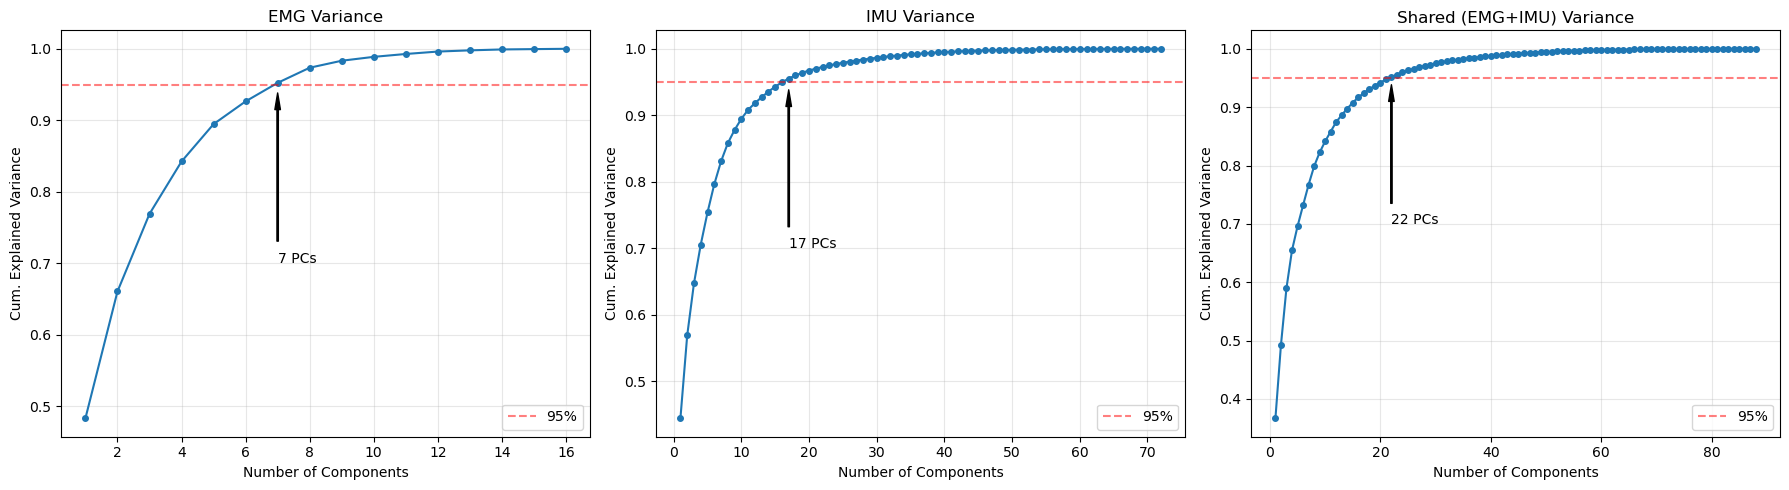

In [5]:
# This will automatically separate EMG/IMU and create the 3 plots
plot_pca_variance(tensor_dict, pid="P124")  # Randomly chose P124

In [6]:
# EMG: 7-8 PCs
# IMU: 16-18 PCs
# EMG+IMU concat: 20-24 PCs --> $B used 50...

In [7]:
print(BASE_CONFIG)

{'knn_metric': 'l1', 'emg_pca_dims': 50, 'imu_pca_dims': 50, 'shared_pca': True, 'pca_level': 'per_sample', 'debug_mode': False, 'use_imu': True, 'shots': [1, 3, 5], 'n_way': 10, 'seed': 42, 'device': 'cuda', 'eval_PIDs': ['P011', 'P006', 'P105', 'P109'], 'use_fixed_rep_split': True, 'all_rep_indices': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'available_gesture_classes': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'aug_support': False, 'aug_n_copies': 0, 'aug_noise_std': 0.05, 'aug_max_shift': 4, 'aug_ch_drop': 0.1}


In [8]:
# $B run
config = BASE_CONFIG | {"tensor_dict": tensor_dict, }

# No encoder -- raw + PCA baselines only.
# To add a neural encoder:
#   results = eval_from_path(..., encoder=model.backbone)
results = eval_from_path(
    tensor_dict_path,
    config,
    encoder         = None,
    shot_conditions = config["shots"],  # This is also passed into config now... used to be command line arugment... can probably simplify
)



#################################################################
#  1-SHOT EVALUATION
#################################################################

  1-shot  10-way  |  metric=l1  |  pca_level=per_sample
  split      : fixed-auto  sup=[1]  qry=[2, 3, 4]...
  feature_fn : flatten (C*T)  |  shared_pca: True
  PID P011 | knn_raw=33.3%  knn_pca=44.4% 
  PID P006 | knn_raw=58.9%  knn_pca=61.1% 
  PID P105 | knn_raw=62.2%  knn_pca=76.7% 
  PID P109 | knn_raw=44.4%  knn_pca=64.4% 

  Method                              Mean      Std   Users
  ──────────────────────────────  ────────  ───────  ──────
  KNN (raw)                         49.72%   13.38%       4
  ProtoNet (raw)                    49.72%   13.38%       4
  KNN (PCA-per_sample)              61.67%   13.29%       4
  ProtoNet (PCA-per_sample)         61.67%   13.29%       4

#################################################################
#  3-SHOT EVALUATION
#################################################################

In [9]:
# $B run but using 95% expl var IMU+EMG dims
config = BASE_CONFIG | {"tensor_dict": tensor_dict, "emg_pca_dims": 24, "imu_pca_dims": 24, }

# No encoder -- raw + PCA baselines only.
# To add a neural encoder:
#   results = eval_from_path(..., encoder=model.backbone)
results = eval_from_path(
    tensor_dict_path,
    config,
    encoder         = None,
    shot_conditions = config["shots"],  # This is also passed into config now... used to be command line arugment... can probably simplify
)



#################################################################
#  1-SHOT EVALUATION
#################################################################

  1-shot  10-way  |  metric=l1  |  pca_level=per_sample
  split      : fixed-auto  sup=[1]  qry=[2, 3, 4]...
  feature_fn : flatten (C*T)  |  shared_pca: True
  PID P011 | knn_raw=33.3%  knn_pca=31.1% 
  PID P006 | knn_raw=58.9%  knn_pca=54.4% 
  PID P105 | knn_raw=62.2%  knn_pca=65.6% 
  PID P109 | knn_raw=44.4%  knn_pca=48.9% 

  Method                              Mean      Std   Users
  ──────────────────────────────  ────────  ───────  ──────
  KNN (raw)                         49.72%   13.38%       4
  ProtoNet (raw)                    49.72%   13.38%       4
  KNN (PCA-per_sample)              50.00%   14.37%       4
  ProtoNet (PCA-per_sample)         50.00%   14.37%       4

#################################################################
#  3-SHOT EVALUATION
#################################################################

In [10]:
# $B run but NO shared PCA between EMG and IMU
config = BASE_CONFIG | {"tensor_dict": tensor_dict, "shared_pca": False, "emg_pca_dims": 8, "imu_pca_dims": 18, }

# No encoder -- raw + PCA baselines only.
# To add a neural encoder:
#   results = eval_from_path(..., encoder=model.backbone)
results = eval_from_path(
    tensor_dict_path,
    config,
    encoder         = None,
    shot_conditions = config["shots"],  # This is also passed into config now... used to be command line arugment... can probably simplify
)



#################################################################
#  1-SHOT EVALUATION
#################################################################

  1-shot  10-way  |  metric=l1  |  pca_level=per_sample
  split      : fixed-auto  sup=[1]  qry=[2, 3, 4]...
  feature_fn : flatten (C*T)  |  shared_pca: False
  PID P011 | knn_raw=33.3%  knn_pca=31.1% 
  PID P006 | knn_raw=58.9%  knn_pca=56.7% 
  PID P105 | knn_raw=62.2%  knn_pca=62.2% 
  PID P109 | knn_raw=44.4%  knn_pca=40.0% 

  Method                              Mean      Std   Users
  ──────────────────────────────  ────────  ───────  ──────
  KNN (raw)                         49.72%   13.38%       4
  ProtoNet (raw)                    49.72%   13.38%       4
  KNN (PCA-per_sample)              47.50%   14.44%       4
  ProtoNet (PCA-per_sample)         47.50%   14.44%       4

#################################################################
#  3-SHOT EVALUATION
################################################################

In [11]:
#"emg_pca_dims":        50,  
#"imu_pca_dims":        50,  
#"shared_pca":          True,  # When this is true, emg_pca_dims and imu_pca_dims must match!!!  # TODO: this does not get used when per_class_pca is used AFAICT
#"pca_level":           "per_sample",  # "global", "per_class", "per_sample"

# Aug pipeline isn't really built up yet
# Also ought to include feature engineering
#"aug_support":         False,
#"aug_n_copies":        0,
#"aug_noise_std":       0.05,
#"aug_max_shift":       4,
#"aug_ch_drop":         0.10,

In [12]:
config = BASE_CONFIG | {"tensor_dict": tensor_dict, "pca_level": "per_class"}

# No encoder -- raw + PCA baselines only.
# To add a neural encoder:
#   results = eval_from_path(..., encoder=model.backbone)
results = eval_from_path(
    tensor_dict_path,
    config,
    encoder         = None,
    shot_conditions = config["shots"],  # This is also passed into config now... used to be command line arugment... can probably simplify
)



#################################################################
#  1-SHOT EVALUATION
#################################################################

  1-shot  10-way  |  metric=l1  |  pca_level=per_class
  split      : fixed-auto  sup=[1]  qry=[2, 3, 4]...
  feature_fn : flatten (C*T)  |  shared_pca: True
  PID P011 | knn_raw=33.3%  knn_pca=44.4% 
  PID P006 | knn_raw=58.9%  knn_pca=61.1% 
  PID P105 | knn_raw=62.2%  knn_pca=76.7% 
  PID P109 | knn_raw=44.4%  knn_pca=64.4% 

  Method                              Mean      Std   Users
  ──────────────────────────────  ────────  ───────  ──────
  KNN (raw)                         49.72%   13.38%       4
  ProtoNet (raw)                    49.72%   13.38%       4
  KNN (PCA-per_class)               61.67%   13.29%       4
  ProtoNet (PCA-per_class)          61.67%   13.29%       4

#################################################################
#  3-SHOT EVALUATION
#################################################################


In [13]:
config = BASE_CONFIG | {"tensor_dict": tensor_dict, "pca_level": "global"}

# No encoder -- raw + PCA baselines only.
# To add a neural encoder:
#   results = eval_from_path(..., encoder=model.backbone)
results = eval_from_path(
    tensor_dict_path,
    config,
    encoder         = None,
    shot_conditions = config["shots"],  # This is also passed into config now... used to be command line arugment... can probably simplify
)



#################################################################
#  1-SHOT EVALUATION
#################################################################

  1-shot  10-way  |  metric=l1  |  pca_level=global
  split      : fixed-auto  sup=[1]  qry=[2, 3, 4]...
  feature_fn : flatten (C*T)  |  shared_pca: True
  PID P011 | knn_raw=33.3%  knn_pca=44.4% 
  PID P006 | knn_raw=58.9%  knn_pca=56.7% 
  PID P105 | knn_raw=62.2%  knn_pca=48.9% 
  PID P109 | knn_raw=44.4%  knn_pca=32.2% 

  Method                              Mean      Std   Users
  ──────────────────────────────  ────────  ───────  ──────
  KNN (raw)                         49.72%   13.38%       4
  ProtoNet (raw)                    49.72%   13.38%       4
  KNN (PCA-global)                  45.56%   10.22%       4
  ProtoNet (PCA-global)             45.56%   10.22%       4

#################################################################
#  3-SHOT EVALUATION
#################################################################

  